In [1]:
import pandas as pd
df=pd.read_json("work.json")
df2=pd.read_json("gadget.json")
df3=pd.read_json("sport.json")
df.head()


,Name,Item Code,Price,Material,Description
0,Felpa da lavoro girocollo elastici in vita,WS5505,"prezzo da € 11,13",65% Poliestere 35% Cotone,Felpa da lavoro con elastici in vita e nei pol...
1,"Polo uomo James & Nicholson easy-care, robusta...",JN1826,"prezzo da € 14,09",50% Cotone 50% Poliestere - 200 g/m²,Polo da lavoro da uomo James & Nicholson è la ...
2,Pantaloni da Lavoro Drill Tasconi Resistenti,CFV061,"prezzo da € 22,78",60% Cotone 40% Poliestere - 245 g/m2,Pantaloni da lavoro Drill progettati per garan...
3,"Rider pile da lavoro con zip, calda e resistente",CFV026,"prezzo da € 23,29",100% Poliestere - 245 g/m2,Pile da lavoro Rider rappresenta la sintesi pe...
4,Gilet alta visibilità Kross CE con strisce rif...,8025,"prezzo da € 1,57",Poliestere,Gilet Catarinfrangente Kross rappresenta la sc...


In [2]:
print(df.shape, df2.shape, df3.shape)

(3933, 5) (4780, 5) (693, 5)


In [3]:
print(df["Name"].isna().sum(), df2["Name"].isna().sum(), df3["Name"].isna().sum())

0 0 0


In [4]:
print(df["Item Code"].isna().sum(), df2["Item Code"].isna().sum(), df3["Item Code"].isna().sum())

0 0 0


In [5]:
print(df["Material"].isna().sum(), df2["Material"].isna().sum(), df3["Material"].isna().sum())

111 155 25


In [6]:
print(df["Description"].isna().sum(), df2["Description"].isna().sum(), df3["Description"].isna().sum())

1 1 0


In [7]:
print(df["Price"].isna().sum(), df2["Price"].isna().sum(), df3["Price"].isna().sum())

0 0 0


In [8]:
print(df["Price"].head(), df2["Price"].head(), df3["Price"].head())

0    prezzo da € 11,13
1    prezzo da € 14,09
2    prezzo da € 22,78
3    prezzo da € 23,29
4     prezzo da € 1,57
Name: Price, dtype: str 0    prezzo da € 1,67
1    prezzo da € 1,71
2    prezzo da € 1,34
3    prezzo da € 0,31
4    prezzo da € 0,31
Name: Price, dtype: str 0    prezzo da € 1,06
1    prezzo da € 2,29
2    prezzo da € 3,56
3    prezzo da € 4,39
4    prezzo da € 5,92
Name: Price, dtype: str


In [9]:
df["Price"]=df["Price"].str.replace(",", ".")
df2["Price"]=df2["Price"].str.replace(",", ".")
df3["Price"]=df3["Price"].str.replace(",", ".")

In [10]:
df["Price"]=df["Price"].str.split("€").str[1]
df2["Price"]=df2["Price"].str.split("€").str[1]
df3["Price"]=df3["Price"].str.split("€").str[1]

In [11]:
df["Price"]=df["Price"].astype(float)
df2["Price"]=df2["Price"].astype(float)
df3["Price"]=df3["Price"].astype(float)

In [12]:
print(df["Price"].head(), df2["Price"].head(), df3["Price"].head())

0    11.13
1    14.09
2    22.78
3    23.29
4     1.57
Name: Price, dtype: float64 0    1.67
1    1.71
2    1.34
3    0.31
4    0.31
Name: Price, dtype: float64 0    1.06
1    2.29
2    3.56
3    4.39
4    5.92
Name: Price, dtype: float64


In [13]:
print(df["Price"].isna().sum(), df2["Price"].isna().sum(), df3["Price"].isna().sum())

215 29 26


In [14]:
print(df.duplicated().sum(), df2.duplicated().sum(), df3.duplicated().sum())

0 0 0


In [15]:
print(df.dtypes, df2.dtypes, df3.dtypes)

Name               str
Item Code          str
Price          float64
Material           str
Description        str
dtype: object Name               str
Item Code          str
Price          float64
Material           str
Description        str
dtype: object Name               str
Item Code          str
Price          float64
Material           str
Description        str
dtype: object


In [16]:
df["Category"]="Work"
df2["Category"]="Gadget"
df3["Category"]="Sport"
data_frames=pd.concat([df, df2, df3])
with pd.ExcelWriter("all_categories.xlsx") as writer:
    data_frames.to_excel(writer, sheet_name="ALL PRODUCTS", index=False)
    df.to_excel(writer, sheet_name="WORK", index=False)
    df2.to_excel(writer, sheet_name="GADGET", index=False)
    df3.to_excel(writer, sheet_name="SPORT", index=False)

In [17]:
data=pd.read_excel("all_categories.xlsx")
data.head()

,Name,Item Code,Price,Material,Description,Category
0,Felpa da lavoro girocollo elastici in vita,WS5505,11.13,65% Poliestere 35% Cotone,Felpa da lavoro con elastici in vita e nei pol...,Work
1,"Polo uomo James & Nicholson easy-care, robusta...",JN1826,14.09,50% Cotone 50% Poliestere - 200 g/m²,Polo da lavoro da uomo James & Nicholson è la ...,Work
2,Pantaloni da Lavoro Drill Tasconi Resistenti,CFV061,22.78,60% Cotone 40% Poliestere - 245 g/m2,Pantaloni da lavoro Drill progettati per garan...,Work
3,"Rider pile da lavoro con zip, calda e resistente",CFV026,23.29,100% Poliestere - 245 g/m2,Pile da lavoro Rider rappresenta la sintesi pe...,Work
4,Gilet alta visibilità Kross CE con strisce rif...,8025,1.57,Poliestere,Gilet Catarinfrangente Kross rappresenta la sc...,Work


In [48]:
sample=pd.concat([df.head(3), df2.head(3), df3.head(3)])
sample.to_excel("samples_data.xlsx", index=False)

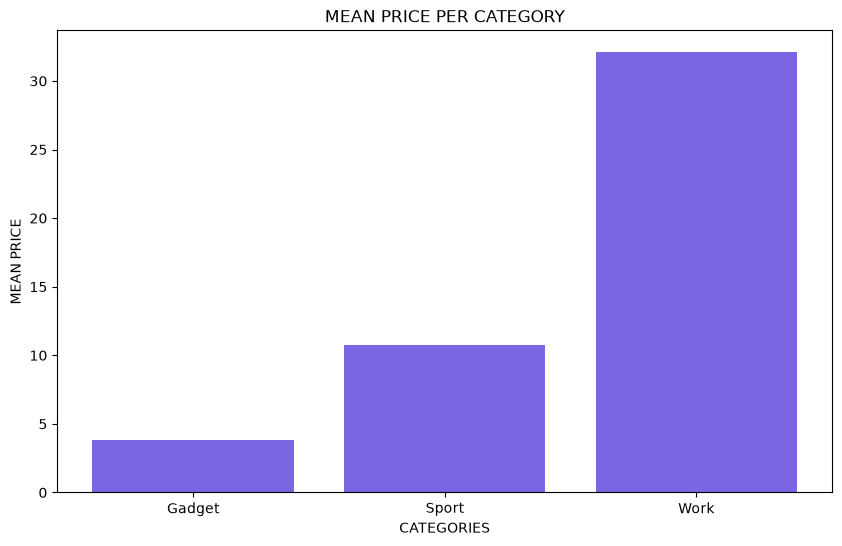

In [42]:
import matplotlib.pyplot as plt
mean_price=data.groupby("Category")["Price"].mean()
plt.figure(figsize=(10, 6))
plt.bar(mean_price.index, mean_price.values, color="#6c52dfe3")
plt.xlabel("CATEGORIES")
plt.ylabel("MEAN PRICE")
plt.title("MEAN PRICE PER CATEGORY")
plt.savefig("mean_price.png", dpi=150, bbox_inches="tight")
plt.show()


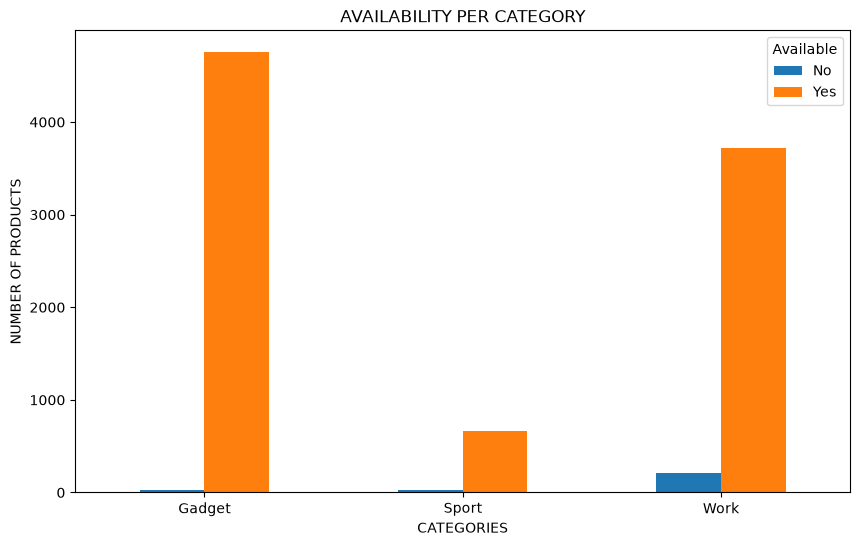

In [45]:
price_mask=data["Price"].isna()
data["Available"]=price_mask
data["Available"]=data["Available"].replace({True: "No", False: "Yes"})
availability=data.groupby("Category")["Available"].value_counts()
availability_wide=availability.unstack()
availability_wide.plot(kind="bar", figsize=(10, 6))
plt.xticks(rotation=0)
plt.legend(title="Available")
plt.xlabel("CATEGORIES")
plt.ylabel("NUMBER OF PRODUCTS")
plt.title("AVAILABILITY PER CATEGORY")
plt.savefig("availability.png", dpi=150, bbox_inches="tight")